# Hyperparameter optimisation

In this notebook we will explore hyperparameter optimisation, and consider a couple of methods for doing so. The goal is for you to know more about what happens under the hood.

## Imports

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import seaborn as sns

hpo_dir = '../hyperparameters/'
sys.path.append(hpo_dir)

# Magic formulae so that changes in the .py files are loaded in here
%load_ext autoreload
%autoreload 2
###

from hpo_helpers import decorate_plot, double_plot

score_label = 'Validation accuracy'

## **Part I: Exploring the results of a hyperparameter search**
### **I.1. Explore the data**
Running a hyperparameter sweep to collect the performance of many hyperparameters can be time-consuming. To save time for this session, we will rely on the results of a previous saved sweep, that was done on the weather image classification project. 
Here, we load the scores of 64 different iterations of the neural network training with different sets of hyperparameters. The results are stored as a **.csv** file.

In [43]:
score_df = pd.read_csv(hpo_dir+'hpo-sweeps/pandas-8-score_df.csv', index_col=0).T.reset_index(drop=True)
score_df.index = score_df.index.rename('epoch')

score_df

,vqysm9hn,pd0az7ll,15p5upxd,kikwbayq,rj73iih8,l1unej7h,lszt8sev,u48n33xl,oigmc4x7,im1xjhdf,...,3n9ilg23,58ccjvw5,2ejzkpo6,4pq7wt5t,s0tla6p7,id1q1bvn,nmso5eki,np7fbnvi,eqvhgzr5,r8i2l2nq
epoch,,,,,,,,,,,,,,,,,,,,,
0,10.2622,11.0861,5.5431,7.0412,14.2322,10.2622,7.2659,12.0599,7.5655,10.8614,...,5.1685,7.5655,5.4682,7.5655,4.7191,4.1948,7.4157,7.5655,9.1386,6.0674
1,17.2285,24.8689,17.2285,29.2884,24.9438,24.1948,9.4382,22.5468,7.5655,36.3296,...,13.4082,8.3895,17.2285,40.6742,8.2397,9.1386,17.2285,29.4382,24.3446,17.1536
2,17.2285,34.0824,17.2285,42.8464,32.6592,29.5880,17.2285,31.6854,7.5655,46.5169,...,12.8839,8.3895,17.2285,50.7865,10.5618,14.9813,17.2285,25.6929,32.5843,20.2247
3,17.2285,37.7528,17.2285,41.0487,34.4569,37.7528,17.2285,38.5019,7.5655,40.9738,...,12.8839,8.3895,17.2285,50.8614,17.2285,24.2697,17.2285,39.6255,37.0037,17.2285
4,17.2285,43.6704,17.2285,49.5880,36.2547,39.8502,17.2285,40.5243,7.4906,43.4457,...,12.5843,11.9101,17.2285,53.7079,21.5730,32.7341,17.2285,44.7191,40.0749,21.8727
5,17.2285,44.8689,17.2285,53.6330,37.0787,38.8764,17.2285,43.3708,7.4157,41.1985,...,12.2846,11.9101,17.2285,57.6779,29.4382,36.6292,17.2285,36.8539,42.8464,17.2285
6,17.2285,46.5918,17.2285,53.0337,37.3783,38.2772,17.2285,44.6442,7.4906,40.8240,...,12.1348,17.2285,17.2285,56.6292,37.7528,38.8015,17.2285,43.6704,44.2697,17.4532
7,17.2285,46.8914,17.2285,54.2322,38.8764,43.0712,17.2285,47.4906,7.4906,43.6704,...,12.1348,17.2285,17.2285,56.1049,38.4270,41.1236,17.2285,42.8464,46.2172,17.2285
8,17.2285,49.8127,17.2285,54.5318,41.1236,42.7715,17.2285,47.7903,7.4157,42.1723,...,12.0599,17.2285,17.2285,59.1011,37.3034,43.1461,17.2285,46.8914,46.8165,17.2285


Each column of the pandas dataframe corresponds to the validation accuracy of the neural network over different training epochs. Let's plot these validation accuracy curves to see the temporal evolution:

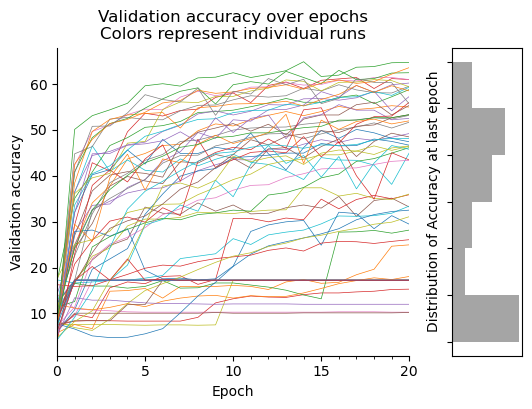

In [44]:
fig, axs = plt.subplots(1,2, figsize=(6,4), width_ratios=[5,1])
score_df.plot(legend=False, ax=axs[0], linewidth=.5)
axs[0].set_title('Validation accuracy over epochs\nColors represent individual runs')
decorate_plot(axs[0], 'Epoch', score_label, legend=False)

axs[1].hist(score_df.iloc[-1,], label='All runs', alpha=0.5, bins=np.arange(10, 71, 10), density=True, orientation='horizontal', color='.3')
axs[1].set_ylabel('Distribution of Accuracy at last epoch')
axs[1].tick_params(labelleft=False, bottom=False, labelbottom=False)

### **I.2. Best hyperparameter sets**
We will now look at the sets of hyperparameters that lead to the best accuracy results.
To do this, we start by loading the configuration of each run that gives us the hyperparameters that were used. We then explore how they influence the best accuracy obtained for each run.

In [45]:
config_dict = json.load(open(hpo_dir+'hpo-sweeps/pandas-8-config_dict.json', 'r'))
df_hyperparams = pd.DataFrame(config_dict).T
best_accuracy_per_run = score_df.max()
df_hyperparams['best_accuracy'] = best_accuracy_per_run

df_hyperparams

,C2,C3,lr,L1_expo,L2_expo,optimizer,best_accuracy
vqysm9hn,21,15,0.006572,2,3,SGD,17.2285
pd0az7ll,10,30,0.000006,9,6,SGD,55.2809
15p5upxd,20,12,0.003062,10,5,AdamW,17.2285
kikwbayq,19,18,0.000164,3,5,AdamW,61.4232
rj73iih8,4,23,0.000004,6,9,SGD,49.2135
...,...,...,...,...,...,...,...
id1q1bvn,31,22,0.000004,5,7,Adam,48.1648
nmso5eki,22,24,0.009812,3,8,Adam,17.2285
np7fbnvi,23,29,0.00167,4,8,AdamW,53.4082
eqvhgzr5,31,25,0.000001,9,9,AdamW,53.3333


The different hyperparameters correspond to the following:

| Hyperparameter name   |      Meaning                                            |
|:---------------------:|:-------------------------------------------------------:|
| C2                    | Number of channels after the first convolutional layer  | 
| C3                    | Number of channels after the second convolutional layer | 
| lr                    | Learning rate                                           |  
| L1_expo               | Number of neurons in the first fully connected layer    |   
| L2_expo               | Number of neurons in the second fully connected layer   |   
| optimizer             | Optimizer used t update weights and biases              | 


> #### **Question 1**
> Which hyperparameters give the 5 best accuracies?
>
> Use the pandas dataframe method `dataframe.nlargest(number_of_elements, sorting_column)`
> What is consistent between them? What is different?

In [46]:
top_5_runs = df_hyperparams.nlargest(5, 'best_accuracy')
top_5_runs

,C2,C3,lr,L1_expo,L2_expo,optimizer,best_accuracy
0fchbmdb,25,19,0.000045,10,5,Adam,64.8689
ekmw8sv2,20,20,0.000042,6,8,Adam,63.5955
v26pmaf0,32,21,0.000257,4,6,Adam,62.9963
kikwbayq,19,18,0.000164,3,5,AdamW,61.4232
rig4q6ue,26,27,0.000005,10,10,Adam,61.4232


<div class="alert alert-block alert-success">
    <b>Warning:</b> We can see that different set of parameters can lead to very similar skill: it is hard to find the optimal set!
</div>

### **I.2. Let's look at the influence of individual hyperparameters**

We will now try to understand which hyperparameter matters. 

>#### **Question 2**:
>Plot the hyperparameters against their best accuracy to inspect their impact on performance. You can choose the hyperparameter you want to plot by changing the value of `hyperparameter_to_test`.
>
>We use `seaborn` to make these plots, which is a great library to plot dataframes : [Seaborn website](https://seaborn.pydata.org/)

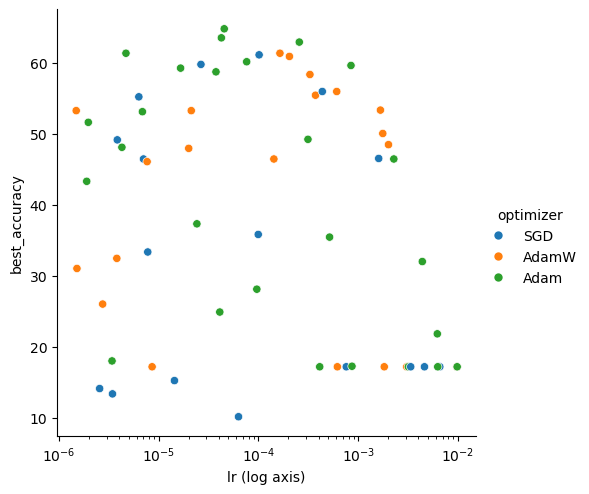

In [47]:
hyperparameter_to_test = 'lr' # Choose a hyperparameter to test from the table above.

sns.relplot(df_hyperparams, x=hyperparameter_to_test, y='best_accuracy', hue='optimizer',)

# We use log scale to compare across learning rates.
if hyperparameter_to_test == 'lr':
    plt.xscale('log')
    plt.xlabel(hyperparameter_to_test + ' (log axis)')

> #### **Question 3**:
> What conclusions can you draw from the above plots? Which hyperparameters affect training the most?

### **I.3. Let's focus on optimizers**
For the optimizers we can compare histograms of the final performance. The following cell produces a histogram of best accuracy for the three optimizers tested. Note that because we picked the optimiser randomly for each run we do not have an equal amount of runs for each optimiser. 

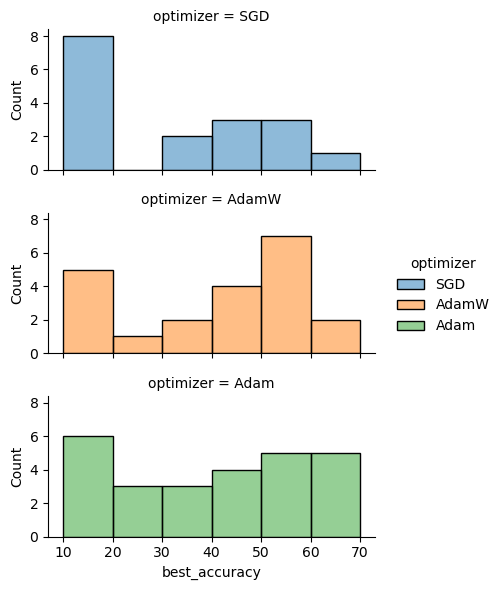

In [48]:
sns.displot(df_hyperparams, x='best_accuracy',hue='optimizer', row='optimizer', bins=np.arange(10, 71, 10), aspect=2, height=2, kind='hist', stat='count')

> #### **Question 3**:
> If you were to set up more experiments which optimisers would you use? Why?

All of these tests inform us on what parameters were important during training, and which sets of parameters give the best results.

## **Part II: Example Hyperparameter Optimisation approaches**
### **II.1. Successive halving**

The successive halving algorithm is designed to greedily discard low-performing models, so that the hyperparamter optimisation budget can be focussed on high-performing configurations. To do so, at every decision step it only keeps the best 1/**H** runs, and discards the rest. It will then run the remaining runs for **H** times as long as for the previous choice. Here we will use **H**=2, so we will discard the bottom half, and for each such discarding choice double the number of epochs trained before the next decision point. If you want to learn more, see e.g. https://blog.ml.cmu.edu/2018/12/12/massively-parallel-hyperparameter-optimization/

As before, we will take advantage of the existing run that we have on record in order to speed up our exploration, and just pretend we get the results epoch per epoch.

> #### **Question 4:**
> Choose the epochs where to do the halvings by changing the `steps_where_halving` list.

Median score at step 0 is 7.79, remaining runs: 33, discarded runs: 31
Median score at step 3 is 26.74, remaining runs: 17, discarded runs: 47
Median score at step 5 is 40.52, remaining runs: 9, discarded runs: 55
Median score at step 10 is 51.39, remaining runs: 5, discarded runs: 59


Text(0.5, 1.0, 'Runs kept vs discarded at all halving steps\nTotal training epochs used: 233 (out of 1344)')

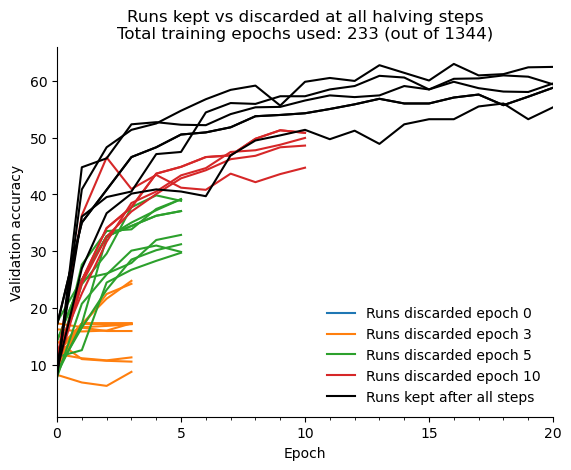

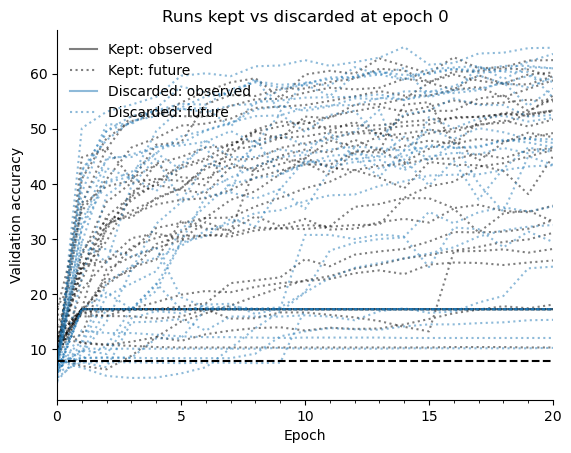

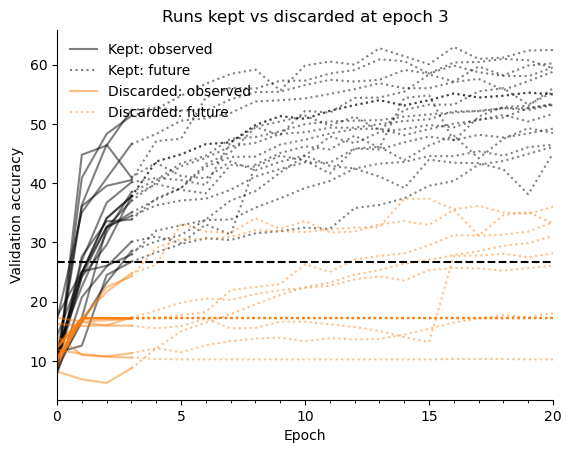

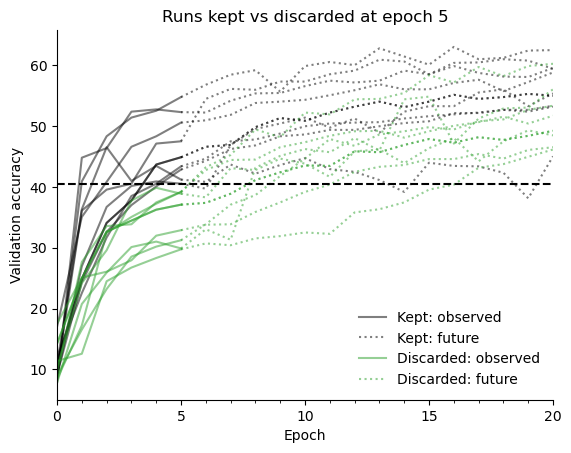

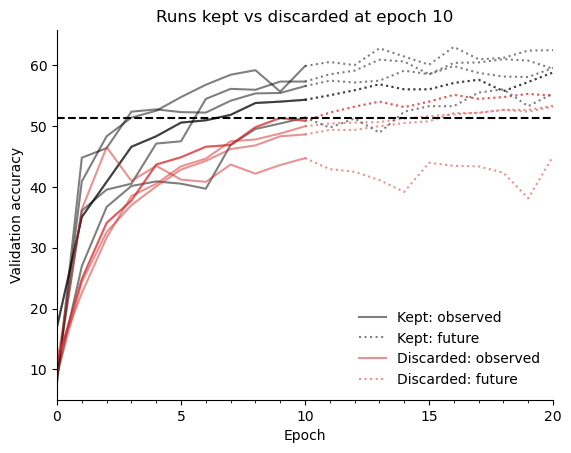

In [70]:
all_runs_kept = list(score_df.columns)
all_runs_discarded = []
score_df_kept = score_df[all_runs_kept]

steps_where_halving = [0,3,5,10]
actual_training_epochs = 0

main_figure,  main_ax = plt.subplots()
for k, step_cutoff in enumerate(steps_where_halving):
    score_at_step = score_df_kept.iloc[step_cutoff]
    median_score_at_step = score_at_step.median()
    runs_above_threshold = score_at_step[score_at_step>=median_score_at_step].index
    runs_below_threshold = score_at_step[score_at_step<median_score_at_step].index
    runs_discarded_at_current_step = list(runs_below_threshold)

    for run in runs_discarded_at_current_step:
        all_runs_discarded.append(run)
        all_runs_kept.remove(run)

    print(f'Median score at step {step_cutoff} is {median_score_at_step:.02f}, remaining runs: {len(all_runs_kept)}, discarded runs: {len(all_runs_discarded)}')
    
    # score_df_kept[runs_above_threshold].iloc[:step_cutoff+1].plot( color='C0', ax=main_ax, label='_nolegend_', color=)
    scores_df_current_kept_runs = score_df_kept[runs_above_threshold]
    scores_df_current_discarded_runs = score_df_kept[runs_below_threshold]

    double_plot(main_ax, range(step_cutoff+1), scores_df_current_discarded_runs.iloc[:step_cutoff+1], label=f'Runs discarded epoch {step_cutoff}', col=f'C{k}')
    actual_training_epochs += scores_df_current_discarded_runs.iloc[:step_cutoff].size
    # Create individual figure
    fig, ax = plt.subplots(1, 1)
    double_plot(ax, range(step_cutoff+1), scores_df_current_kept_runs.iloc[:step_cutoff+1], label='Kept: observed', col='k', aa=0.5)
    double_plot(ax, range(step_cutoff,21), scores_df_current_kept_runs.iloc[step_cutoff:], col='k', label='Kept: future', ll=':', aa=0.5)
    double_plot(ax, range(step_cutoff+1), scores_df_current_discarded_runs.iloc[:step_cutoff+1], label='Discarded: observed', col=f'C{k}', aa=0.5)
    double_plot(ax, range(step_cutoff,21), scores_df_current_discarded_runs.iloc[step_cutoff:], col=f'C{k}', label='Discarded: future', ll=':', aa=0.5)
    decorate_plot(ax, 'Epoch', score_label, legend=True)
    ax.axhline(y=median_score_at_step, color='k', linestyle='--')
    ax.set_title(f'Runs kept vs discarded at epoch {step_cutoff}')
    score_df_kept = score_df[all_runs_kept]

# double_plot(main_ax, range(21), scores_df_current_kept_runs.iloc[:step_cutoff+1], label=f'Runs discarded epoch {step_cutoff}', col=f'C{k}')
double_plot(main_ax, range(21), scores_df_current_kept_runs, label=f'Runs kept after all steps', col=f'k',)
actual_training_epochs += scores_df_current_kept_runs.size

main_ax.legend()
decorate_plot(main_ax, 'Epoch', score_label, legend=True)
main_ax.set_title(f'Runs kept vs discarded at all halving steps\nTotal training epochs used: {actual_training_epochs} (out of {score_df.size})')

In [67]:
scores_df_current_kept_runs.size/21

33.0

In [68]:
actual_training_epochs/score_df.size

0.515625

76

> #### **Question 6:** 
> Do you think the algorithm is reasonable in the runs that it stops early?

### **II.1. Learning curves**
An alternative approach is to treat the evolution of the training curves as a prediction problem, and train a simpler machine learning model to predict the evolution over epochs of the validation accuracy. Instead of discarding the runs that are have the lowest accuracy at a given step, we discard the runs with the lowest predicted accuracy in the future.

Here we will train linear regression models to predict future validation accuracies based on the first **K** epochs. These could then be used to decide which runs to continue and which to stop early.

In [17]:
from sklearn.linear_model import LinearRegression

> ### Question 7:
> Fill in the remaining code so we can predict future accuracy with a Linear Regression Model.

In [ ]:
K = 5 # How many epochs we run for before predicting the evolution. Used to split into X and y.
X = score_df[:K].T
y = score_df[K:].T

N = 50 # How many runs to use for training. Used to split into training and validation subsets.
X_train = X[:N]
y_train = y[:N]
X_val = X[N:]
y_val = y[N:]

# We fit a linear regression model to the training data
reg = LinearRegression().fit(X_train, y_train)

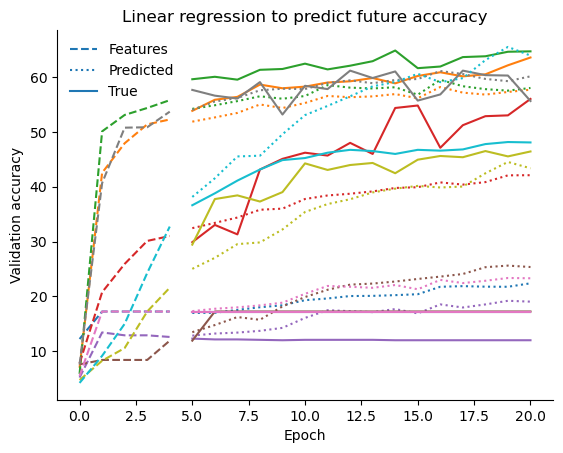

In [30]:
# Plot the predicted validation curves
fig, ax = plt.subplots()
for ii in range(10):
    X_ii = X_val.iloc[[ii]]
    y_ii = y_val.iloc[[ii]]
    ax.plot(range(K), X_ii.values[0], '--', c=f'C{ii}',
            label='Features' if ii == 0 else None);
    ax.plot(range(K, 21), reg.predict(X_ii).T, ':', c=f'C{ii}',
            label='Predicted' if ii == 0 else None);
    ax.plot(range(K, 21), y_ii.values[0], c=f'C{ii}',
            label='True' if ii == 0 else None);
ax.set_xlabel('Epoch')
ax.set_ylabel(score_label)
ax.spines[['right', 'top']].set_visible(False)
ax.set_title('Linear regression to predict future accuracy')
ax.legend(frameon=False);

> ### Question 8:
> How well do the predictions work? What are they good at? How much computation could you save by using the predictions as heuristics for final performance to limit the number of models trained to end? 
>
>What happens if you change **K** and **N**?